In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns.tolist()
train_end = len(prices) - 250

def sharpe_ratio(return_series):
    daily_volatility = return_series.std()
    if daily_volatility <= 0 or pd.isna(daily_volatility):
        return np.nan
    return np.sqrt(250) * return_series.mean() / daily_volatility

def performance_summary(return_series):
    return pd.Series({
        "mean_daily_return": return_series.mean(),
        "daily_volatility": return_series.std(),
        "annualised_sharpe": sharpe_ratio(return_series),
        "total_return": (1 + return_series).prod() - 1,
    })

def train_test_all_summary(return_series):
    train_returns = return_series.iloc[:train_end]
    test_returns = return_series.iloc[train_end:]
    return pd.DataFrame({
        "train": performance_summary(train_returns),
        "test": performance_summary(test_returns),
        "all": performance_summary(return_series),
    })


In [8]:
# Momentum sleeve: use the universe selected by training Sharpe on the first 250 price rows.
momentum_assets = [
    "NPCK", "SRNA", "NWIG", "OTCS", "RCRI", "FARS", "HUXZ", "AENO",
    "HTRK", "DUCT", "ILVX", "MMBT", "HETT", "HRND", "IHOZ", "ELLT",
    "ANSO", "HRET", "ACAC", "MDGI", "RRES", "MSDP", "CUBO", "SMAH",
    "DIHO", "BLBT", "MTNS", "LSST", "ACIX", "ITPA", "EORC", "ALUT", "EAFC",
]

lookbacks = [5, 10, 20, 30, 40, 50, 60, 70]
past_returns = returns.shift(1)
z_scores = {}

for lookback in lookbacks:
    momentum = past_returns.rolling(lookback).sum()
    volatility = past_returns.rolling(lookback).std()
    vol_normalised = momentum / volatility.replace(0, np.nan)
    cross_sectional_mean = vol_normalised.mean(axis=1)
    cross_sectional_std = vol_normalised.std(axis=1)
    z_scores[lookback] = vol_normalised.sub(cross_sectional_mean, axis=0).div(cross_sectional_std, axis=0)

def make_candidate_weight_sets(lookbacks, grid_step):
    units = int(round(1 / grid_step))
    candidates = []

    def build(index, remaining_units, current_weights):
        if index == len(lookbacks) - 1:
            current_weights[lookbacks[index]] = remaining_units * grid_step
            candidates.append({lookback: round(weight, 10) for lookback, weight in current_weights.items()})
            return

        lookback = lookbacks[index]
        for weight_units in range(remaining_units + 1):
            next_weights = current_weights.copy()
            next_weights[lookback] = weight_units * grid_step
            build(index + 1, remaining_units - weight_units, next_weights)

    build(0, units, {})
    return candidates

grid_step = 0.20
candidate_weight_sets = make_candidate_weight_sets(lookbacks, grid_step)
momentum_weight_rows = []

for asset in momentum_assets:
    asset_results = []

    for candidate_weights in candidate_weight_sets:
        candidate_signal = sum(candidate_weights[lookback] * z_scores[lookback][asset] for lookback in lookbacks)
        candidate_returns = (candidate_signal.shift(1) * returns[asset]).dropna()
        train_returns = candidate_returns.iloc[:train_end]
        test_returns = candidate_returns.iloc[train_end:]

        asset_results.append({
            "asset": asset,
            **{f"a{lookback}": candidate_weights[lookback] for lookback in lookbacks},
            "train_sharpe": sharpe_ratio(train_returns),
            "test_sharpe": sharpe_ratio(test_returns),
            "train_total_return": (1 + train_returns).prod() - 1,
            "test_total_return": (1 + test_returns).prod() - 1,
        })

    best_asset_row = pd.DataFrame(asset_results).sort_values("train_sharpe", ascending=False).iloc[0]
    momentum_weight_rows.append(best_asset_row)

momentum_horizon_weights = pd.DataFrame(momentum_weight_rows).set_index("asset")
display(momentum_horizon_weights.sort_values("train_sharpe", ascending=False))


,a5,a10,a20,a30,a40,a50,a60,a70,train_sharpe,test_sharpe,train_total_return,test_total_return
asset,,,,,,,,,,,,
NPCK,0.6,0.0,0.0,0.4,0.0,0.0,0.0,0.0,2.553687,-0.327011,0.943999,-0.055252
SRNA,0.4,0.0,0.6,0.0,0.0,0.0,0.0,0.0,2.544426,1.025778,0.931728,0.200316
NWIG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.088738,-0.117564,0.886049,-0.069995
OTCS,0.2,0.0,0.0,0.0,0.0,0.8,0.0,0.0,1.905466,-1.391759,1.372023,-0.344606
RCRI,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.733036,-1.174521,1.210037,-0.464412
FARS,0.2,0.0,0.0,0.0,0.8,0.0,0.0,0.0,1.687799,-0.396019,0.496937,-0.069856
HUXZ,0.8,0.2,0.0,0.0,0.0,0.0,0.0,0.0,1.494183,0.705075,0.498092,0.126412
AENO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.382322,0.379337,0.437287,0.049482
HTRK,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.342964,-2.046563,0.364043,-0.361152


In [9]:
momentum_signals = pd.DataFrame(0.0, index=returns.index, columns=assets)

for asset in momentum_assets:
    asset_weights = momentum_horizon_weights.loc[asset]
    momentum_signals[asset] = sum(asset_weights[f"a{lookback}"] * z_scores[lookback][asset] for lookback in lookbacks)

momentum_gross_signal = momentum_signals.abs().sum(axis=1)
momentum_positions = momentum_signals.div(momentum_gross_signal.replace(0, np.nan), axis=0).fillna(0)
momentum_strategy_returns = (momentum_positions.shift(1) * returns).sum(axis=1).dropna()

display(train_test_all_summary(momentum_strategy_returns))


,train,test,all
mean_daily_return,0.001257,0.000175,0.000716
daily_volatility,0.004205,0.004762,0.004520
annualised_sharpe,4.728223,0.580383,2.505015
total_return,0.366122,0.041720,0.423116


In [10]:
# Pairs sleeve: use the remaining 39 assets, identified using training data only.
pairs_assets = [asset for asset in assets if asset not in momentum_assets]
train_prices = prices.iloc[:train_end]

pair_rows = []

for i, asset_y in enumerate(pairs_assets):
    for asset_x in pairs_assets[i + 1:]:
        y = train_prices[asset_y]
        x = sm.add_constant(train_prices[asset_x])
        model = sm.OLS(y, x).fit()
        alpha = model.params["const"]
        beta = model.params[asset_x]
        train_spread = model.resid
        adf_stat, adf_p_value, *_ = adfuller(train_spread.dropna())

        pair_rows.append({
            "asset_y": asset_y,
            "asset_x": asset_x,
            "alpha": alpha,
            "beta": beta,
            "adf_stat": adf_stat,
            "adf_p_value": adf_p_value,
            "r_squared": model.rsquared,
            "spread_std": train_spread.std(),
        })

pair_results = pd.DataFrame(pair_rows).sort_values(["adf_p_value", "r_squared"], ascending=[True, False])
stationary_pairs = pair_results[
    (pair_results["adf_p_value"] < 0.05) &
    (pair_results["r_squared"] > 0.50)
].copy()

max_pairs = 10
used_assets = set()
selected_pair_rows = []

for _, row in stationary_pairs.iterrows():
    if row["asset_y"] in used_assets or row["asset_x"] in used_assets:
        continue

    selected_pair_rows.append(row)
    used_assets.add(row["asset_y"])
    used_assets.add(row["asset_x"])

    if len(selected_pair_rows) >= max_pairs:
        break

selected_pairs = pd.DataFrame(selected_pair_rows).reset_index(drop=True)
print("Pairs assets:", len(pairs_assets))
print("Stationary pairs found:", len(stationary_pairs))
print("Selected non-overlapping pairs:", len(selected_pairs))
display(selected_pairs)


Pairs assets: 18
Stationary pairs found: 5
Selected non-overlapping pairs: 4


,asset_y,asset_x,alpha,beta,adf_stat,adf_p_value,r_squared,spread_std
0,GARI,EELT,23.025273,-0.085821,-4.860302,0.000042,0.527477,0.910287
1,ULXY,FCSG,82.495174,-1.189094,-4.519209,0.000182,0.514864,3.424638
2,AGVF,BENI,27.427087,3.450960,-3.680987,0.004389,0.609323,5.181822
3,CTGI,NGTE,35.422539,1.003893,-3.255753,0.016976,0.569597,7.545110


In [11]:
def build_pair_positions(prices, selected_pairs, rolling_window=60, entry_z=2.0, exit_z=0.5):
    pair_positions = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)

    for _, pair in selected_pairs.iterrows():
        asset_y = pair["asset_y"]
        asset_x = pair["asset_x"]
        alpha = pair["alpha"]
        beta = pair["beta"]

        spread = prices[asset_y] - alpha - beta * prices[asset_x]
        spread_mean = spread.shift(1).rolling(rolling_window).mean()
        spread_std = spread.shift(1).rolling(rolling_window).std()
        z_score = (spread.shift(1) - spread_mean) / spread_std.replace(0, np.nan)

        state = 0
        y_weight = pd.Series(0.0, index=prices.index)
        x_weight = pd.Series(0.0, index=prices.index)

        for t in range(len(prices)):
            z = z_score.iloc[t]

            if pd.isna(z):
                state = 0
            elif state == 0:
                if z > entry_z:
                    state = -1
                elif z < -entry_z:
                    state = 1
            elif abs(z) < exit_z:
                state = 0

            gross = abs(1) + abs(beta)
            y_weight.iloc[t] = state / gross
            x_weight.iloc[t] = -state * beta / gross

        pair_positions[asset_y] += y_weight / len(selected_pairs)
        pair_positions[asset_x] += x_weight / len(selected_pairs)

    return pair_positions


pair_positions = build_pair_positions(prices, selected_pairs, rolling_window=60, entry_z=2.0, exit_z=0.5)
pair_strategy_returns = (pair_positions * returns).sum(axis=1).dropna()

display(train_test_all_summary(pair_strategy_returns))


,train,test,all
mean_daily_return,0.000862,0.000397,0.000629
daily_volatility,0.003617,0.005810,0.004840
annualised_sharpe,3.767079,1.080412,2.056083
total_return,0.238281,0.099686,0.361720


50/50 combined summary


,train,test,all
mean_daily_return,0.001060,0.000286,0.000673
daily_volatility,0.002720,0.003970,0.003422
annualised_sharpe,6.160330,1.138470,3.108824
total_return,0.301926,0.071972,0.395628


Best train-selected sleeve blend


,momentum_weight,pairs_weight,train_sharpe,test_sharpe,train_total_return,test_total_return
10,0.50,0.50,6.160330,1.138470,0.301926,0.071972
11,0.55,0.45,6.147918,1.109442,0.308325,0.069057
9,0.45,0.55,6.107593,1.158057,0.295533,0.074861
12,0.60,0.40,6.078176,1.070904,0.314729,0.066117
8,0.40,0.60,5.987408,1.168867,0.289146,0.077725
13,0.65,0.35,5.962386,1.023469,0.321138,0.063152
14,0.70,0.30,5.812961,0.968401,0.327551,0.060162
7,0.35,0.65,5.803937,1.171980,0.282765,0.080563
15,0.75,0.25,5.641600,0.907450,0.333970,0.057148
6,0.30,0.70,5.567116,1.168693,0.276390,0.083375


,train,test,all
mean_daily_return,0.001060,0.000286,0.000673
daily_volatility,0.002720,0.003970,0.003422
annualised_sharpe,6.160330,1.138470,3.108824
total_return,0.301926,0.071972,0.395628


<Axes: title={'center': 'Momentum + pairs cumulative returns'}>

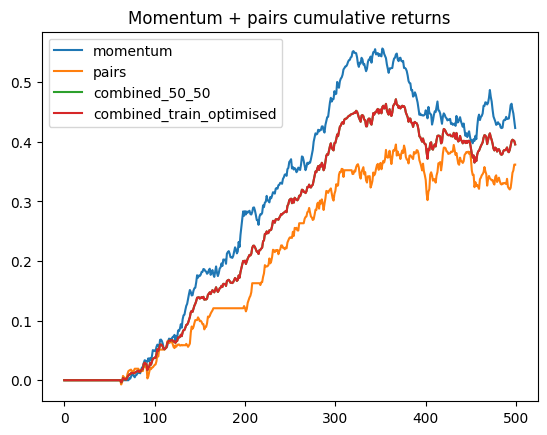

In [12]:
strategy_returns = pd.DataFrame({
    "momentum": momentum_strategy_returns,
    "pairs": pair_strategy_returns,
}).dropna()

combined_returns_50_50 = 0.50 * strategy_returns["momentum"] + 0.50 * strategy_returns["pairs"]

blend_rows = []
for momentum_weight in np.arange(0, 1.01, 0.05):
    pair_weight = 1 - momentum_weight
    candidate_returns = momentum_weight * strategy_returns["momentum"] + pair_weight * strategy_returns["pairs"]
    train_candidate = candidate_returns.iloc[:train_end]
    test_candidate = candidate_returns.iloc[train_end:]
    blend_rows.append({
        "momentum_weight": momentum_weight,
        "pairs_weight": pair_weight,
        "train_sharpe": sharpe_ratio(train_candidate),
        "test_sharpe": sharpe_ratio(test_candidate),
        "train_total_return": (1 + train_candidate).prod() - 1,
        "test_total_return": (1 + test_candidate).prod() - 1,
    })

blend_results = pd.DataFrame(blend_rows).sort_values("train_sharpe", ascending=False)
best_blend = blend_results.iloc[0]
combined_returns_train_optimised = (
    best_blend["momentum_weight"] * strategy_returns["momentum"] +
    best_blend["pairs_weight"] * strategy_returns["pairs"]
)

print("50/50 combined summary")
display(train_test_all_summary(combined_returns_50_50))

print("Best train-selected sleeve blend")
display(blend_results.head(10))
display(train_test_all_summary(combined_returns_train_optimised))

cumulative_returns = pd.DataFrame({
    "momentum": (1 + strategy_returns["momentum"]).cumprod() - 1,
    "pairs": (1 + strategy_returns["pairs"]).cumprod() - 1,
    "combined_50_50": (1 + combined_returns_50_50).cumprod() - 1,
    "combined_train_optimised": (1 + combined_returns_train_optimised).cumprod() - 1,
})

cumulative_returns.plot(title="Momentum + pairs cumulative returns")
